In [ ]:
import os
import sys
import json
import time
import shutil
import base64
import subprocess
import concurrent.futures
from pathlib import Path
from datetime import datetime
from textwrap import dedent

def run_cmd(cmd, check=True, capture=False):
    print(f"\n$ {' '.join(cmd)}")
    result = subprocess.run(
        cmd,
        check=check,
        text=True,
        stdout=subprocess.PIPE if capture else None,
        stderr=subprocess.STDOUT if capture else None,
    )
    if capture and result.stdout:
        print(result.stdout[:4000])
    return result


print("Installing CloakBrowser and helper packages...")
run_cmd([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "cloakbrowser", "playwright", "pandas", "beautifulsoup4"
])

print("\nInstalling Chromium runtime dependencies for Colab...")
try:
    run_cmd([sys.executable, "-m", "playwright", "install-deps", "chromium"], check=False)
except Exception as e:
    print("Dependency installer warning:", repr(e))


from cloakbrowser import (
    launch,
    launch_context,
    launch_persistent_context,
    ensure_binary,
    binary_info,
)

import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import display, Image


WORKDIR = Path("/content/cloakbrowser_advanced_tutorial")
WORKDIR.mkdir(parents=True, exist_ok=True)

SCREENSHOT_PATH = WORKDIR / "cloakbrowser_result.png"
STORAGE_STATE_PATH = WORKDIR / "storage_state.json"
PROFILE_DIR = WORKDIR / "persistent_profile"


print("\nPreparing CloakBrowser binary...")

try:
    ensure_binary()
except Exception as e:
    print("Binary setup warning:", repr(e))

print("\nCloakBrowser binary info:")

try:
    info = binary_info()
    print(json.dumps(info, indent=2, default=str))
except Exception as e:
    print("Could not read binary info:", repr(e))

In [ ]:
def make_data_url(html: str) -> str:
    encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
    return f"data:text/html;base64,{encoded}"


def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def safe_close(obj, label="object"):
    try:
        if obj:
            obj.close()
    except Exception as e:
        print(f"Warning while closing {label}: {e}")


def run_sync_browser_job_in_thread(fn, *args, **kwargs):
    """
    Google Colab and Jupyter already run an asyncio event loop.

    CloakBrowser currently exposes Playwright-style sync helpers such as:
      - launch()
      - launch_context()
      - launch_persistent_context()

    Playwright's sync API cannot run inside an already-running event loop.
    Therefore, we run the entire browser automation job inside a separate thread.
    """
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(fn, *args, **kwargs)
        return future.result()


test_page_html = dedent("""
<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>CloakBrowser Local Automation Lab</title>
  <style>
    body {
      font-family: system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
      max-width: 900px;
      margin: 40px auto;
      padding: 24px;
      line-height: 1.5;
      background: #f7f7f7;
      color: #222;
    }
    .card {
      background: white;
      border-radius: 18px;
      padding: 24px;
      box-shadow: 0 8px 30px rgba(0,0,0,0.08);
      margin-bottom: 18px;
    }
    label {
      display: block;
      margin-top: 12px;
      font-weight: 600;
    }
    input, textarea, button {
      width: 100%;
      box-sizing: border-box;
      padding: 12px;
      margin-top: 8px;
      border: 1px solid #ccc;
      border-radius: 12px;
      font-size: 15px;
    }
    button {
      cursor: pointer;
      background: #111;
      color: white;
      font-weight: 700;
    }
    pre {
      background: #111;
      color: #00ff99;
      padding: 16px;
      overflow-x: auto;
      border-radius: 12px;
    }
  </style>
</head>
<body>
  <div class="card">
    <h1>CloakBrowser Local Automation Lab</h1>
    <p>
      This page runs locally from a data URL. We use it to inspect browser-visible
      properties and demonstrate Playwright-style interaction safely.
    </p>
  </div>

  <div class="card">
    <h2>Interaction Form</h2>

    <label>Name</label>
    <input id="name" placeholder="Type your name here">

    <label>Message</label>
    <textarea id="message" rows="4" placeholder="Type a short message"></textarea>

    <button id="submit">Submit Local Form</button>
    <p id="status">Waiting for interaction...</p>
  </div>

  <div class="card">
    <h2>Browser Signals</h2>
    <pre id="signals"></pre>
  </div>

  <script>
    async function collectSignals() {
      const canvas = document.createElement("canvas");
      const gl = canvas.getContext("webgl") || canvas.getContext("experimental-webgl");

      let webglVendor = null;
      let webglRenderer = null;

      if (gl) {
        const debugInfo = gl.getExtension("WEBGL_debug_renderer_info");
        if (debugInfo) {
          webglVendor = gl.getParameter(debugInfo.UNMASKED_VENDOR_WEBGL);
          webglRenderer = gl.getParameter(debugInfo.UNMASKED_RENDERER_WEBGL);
        }
      }

      const signals = {
        title: document.title,
        userAgent: navigator.userAgent,
        webdriver: navigator.webdriver,
        platform: navigator.platform,
        languages: navigator.languages,
        language: navigator.language,
        hardwareConcurrency: navigator.hardwareConcurrency,
        deviceMemory: navigator.deviceMemory || null,
        pluginsLength: navigator.plugins ? navigator.plugins.length : null,
        chromeObjectPresent: typeof window.chrome === "object",
        timezone: Intl.DateTimeFormat().resolvedOptions().timeZone,
        screen: {
          width: screen.width,
          height: screen.height,
          colorDepth: screen.colorDepth,
          pixelDepth: screen.pixelDepth
        },
        viewport: {
          innerWidth: window.innerWidth,
          innerHeight: window.innerHeight,
          devicePixelRatio: window.devicePixelRatio
        },
        webglVendor,
        webglRenderer,
        localStorageWorks: (() => {
          try {
            localStorage.setItem("cloakbrowser_test", "ok");
            return localStorage.getItem("cloakbrowser_test") === "ok";
          } catch (e) {
            return false;
          }
        })()
      };

      document.getElementById("signals").textContent = JSON.stringify(signals, null, 2);
      return signals;
    }

    document.getElementById("submit").addEventListener("click", () => {
      const name = document.getElementById("name").value;
      const message = document.getElementById("message").value;

      localStorage.setItem("tutorial_name", name);
      localStorage.setItem("tutorial_message", message);

      document.getElementById("status").textContent =
        `Saved locally for ${name}: ${message}`;
    });

    collectSignals();
  </script>
</body>
</html>
""").strip()

TEST_PAGE_URL = make_data_url(test_page_html)

In [ ]:
def cloakbrowser_tutorial_job():
    results = {
        "basic_launch": None,
        "advanced_context": None,
        "storage_restore": None,
        "persistent_profile": None,
        "rendered_extraction": None,
        "static_parsing": None,
        "errors": [],
    }

    print_section("1. Basic CloakBrowser launch")

    browser = None

    try:
        browser = launch(
            headless=True,
            humanize=True,
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        page = browser.new_page()
        page.goto("https://example.com", wait_until="domcontentloaded", timeout=60000)

        results["basic_launch"] = {
            "title": page.title(),
            "body_preview": page.locator("body").inner_text(timeout=15000)[:300],
            "url": page.url,
        }

        print(json.dumps(results["basic_launch"], indent=2))

    except Exception as e:
        error = {
            "section": "basic_launch",
            "error": repr(e),
        }
        results["errors"].append(error)
        print(error)

    finally:
        safe_close(browser, "basic browser")

    print_section("2. Advanced context launch with custom browser context")

    context = None

    try:
        context = launch_context(
            headless=True,
            humanize=True,
            viewport={"width": 1365, "height": 768},
            locale="en-US",
            timezone_id="America/New_York",
            color_scheme="light",
            extra_http_headers={
                "Accept-Language": "en-US,en;q=0.9",
                "X-Tutorial-Run": "cloakbrowser-colab",
            },
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        page = context.new_page()
        page.goto(TEST_PAGE_URL, wait_until="domcontentloaded", timeout=60000)

        page.locator("#name").fill("CloakBrowser Colab User")
        page.locator("#message").fill(
            "We are testing safe local browser automation in Google Colab."
        )
        page.locator("#submit").click()

        page.wait_for_timeout(1000)

        signals = page.evaluate("() => collectSignals()")
        status_text = page.locator("#status").inner_text()

        page.screenshot(path=str(SCREENSHOT_PATH), full_page=True)
        context.storage_state(path=str(STORAGE_STATE_PATH))

        results["advanced_context"] = {
            "status_text": status_text,
            "signals": signals,
            "screenshot_path": str(SCREENSHOT_PATH),
            "storage_state_path": str(STORAGE_STATE_PATH),
        }

        print(json.dumps(results["advanced_context"], indent=2, default=str))

    except Exception as e:
        error = {
            "section": "advanced_context",
            "error": repr(e),
        }
        results["errors"].append(error)
        print(error)

    finally:
        safe_close(context, "advanced context")

    print_section("3. Restore localStorage using storage_state")

    restored_context = None

    try:
        restored_context = launch_context(
            headless=True,
            humanize=True,
            storage_state=str(STORAGE_STATE_PATH),
            viewport={"width": 1365, "height": 768},
            locale="en-US",
            timezone_id="America/New_York",
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        restored_page = restored_context.new_page()
        restored_page.goto(TEST_PAGE_URL, wait_until="domcontentloaded", timeout=60000)

        restored_values = restored_page.evaluate("""
        () => ({
          tutorial_name: localStorage.getItem("tutorial_name"),
          tutorial_message: localStorage.getItem("tutorial_message"),
          cloakbrowser_test: localStorage.getItem("cloakbrowser_test")
        })
        """)

        results["storage_restore"] = restored_values

        print(json.dumps(restored_values, indent=2))

    except Exception as e:
        error = {
            "section": "storage_restore",
            "error": repr(e),
        }
        results["errors"].append(error)
        print(error)

    finally:
        safe_close(restored_context, "restored context")

In [ ]:
    print_section("4. Persistent profile demonstration")

    if PROFILE_DIR.exists():
        shutil.rmtree(PROFILE_DIR)

    try:
        ctx1 = launch_persistent_context(
            str(PROFILE_DIR),
            headless=True,
            humanize=True,
            viewport={"width": 1280, "height": 720},
            locale="en-US",
            timezone_id="America/New_York",
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        p1 = ctx1.new_page()
        p1.goto(TEST_PAGE_URL, wait_until="domcontentloaded", timeout=60000)

        p1.evaluate("""
        () => {
          localStorage.setItem("persistent_profile_demo", "saved_across_browser_restarts");
          localStorage.setItem("persistent_profile_timestamp", new Date().toISOString());
        }
        """)

        first_value = p1.evaluate("() => localStorage.getItem('persistent_profile_demo')")
        ctx1.close()

        ctx2 = launch_persistent_context(
            str(PROFILE_DIR),
            headless=True,
            humanize=True,
            viewport={"width": 1280, "height": 720},
            locale="en-US",
            timezone_id="America/New_York",
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        p2 = ctx2.new_page()
        p2.goto(TEST_PAGE_URL, wait_until="domcontentloaded", timeout=60000)

        second_value = p2.evaluate(
            "() => localStorage.getItem('persistent_profile_demo')"
        )
        second_timestamp = p2.evaluate(
            "() => localStorage.getItem('persistent_profile_timestamp')"
        )

        ctx2.close()

        persistent_results = {
            "first_run_value": first_value,
            "second_run_value": second_value,
            "second_run_timestamp": second_timestamp,
            "profile_dir": str(PROFILE_DIR),
            "persisted_successfully": first_value == second_value and second_value is not None,
        }

        results["persistent_profile"] = persistent_results

        print(json.dumps(persistent_results, indent=2))

    except Exception as e:
        error = {
            "section": "persistent_profile",
            "error": repr(e),
        }
        results["errors"].append(error)
        print(error)

    print_section("5. Browser-rendered extraction plus static parsing")

    browser = None

    try:
        browser = launch(
            headless=True,
            humanize=True,
            args=[
                "--no-sandbox",
                "--disable-dev-shm-usage",
            ],
        )

        page = browser.new_page()
        page.goto("https://example.com", wait_until="domcontentloaded", timeout=60000)

        rendered = {
            "title": page.title(),
            "h1": page.locator("h1").inner_text(timeout=15000),
            "paragraph": page.locator("p").first.inner_text(timeout=15000),
            "url": page.url,
            "captured_at": datetime.utcnow().isoformat() + "Z",
        }

        html = page.content()
        soup = BeautifulSoup(html, "html.parser")

        parsed = {
            "static_title": soup.title.get_text(strip=True) if soup.title else None,
            "static_h1": soup.find("h1").get_text(strip=True) if soup.find("h1") else None,
            "links": [
                {
                    "text": a.get_text(strip=True),
                    "href": a.get("href"),
                }
                for a in soup.find_all("a")
            ],
        }

        results["rendered_extraction"] = rendered
        results["static_parsing"] = parsed

        print("Rendered extraction:")
        print(json.dumps(rendered, indent=2))

        print("\nStatic parsing:")
        print(json.dumps(parsed, indent=2))

    except Exception as e:
        error = {
            "section": "rendered_extraction",
            "error": repr(e),
        }
        results["errors"].append(error)
        print(error)

    finally:
        safe_close(browser, "extraction browser")

    return results

Installing CloakBrowser and helper packages...

$ /usr/bin/python3 -m pip install -q -U cloakbrowser playwright pandas beautifulsoup4

Installing Chromium runtime dependencies for Colab...

$ /usr/bin/python3 -m playwright install-deps chromium

Preparing CloakBrowser binary...

CloakBrowser binary info:
{
  "version": "146.0.7680.177.4",
  "bundled_version": "146.0.7680.177.3",
  "platform": "linux-x64",
  "binary_path": "/root/.cloakbrowser/chromium-146.0.7680.177.4/chrome",
  "installed": true,
  "cache_dir": "/root/.cloakbrowser/chromium-146.0.7680.177.4",
  "download_url": "https://cloakbrowser.dev/chromium-v146.0.7680.177.4/cloakbrowser-linux-x64.tar.gz"
}

1. Basic CloakBrowser launch
{
  "title": "Example Domain",
  "body_preview": "Example Domain\n\nThis domain is for use in documentation examples without needing permission. Avoid use in operations.\n\nLearn more",
  "url": "https://example.com/"
}

2. Advanced context launch with custom browser context
{
  "status_text": "Wai

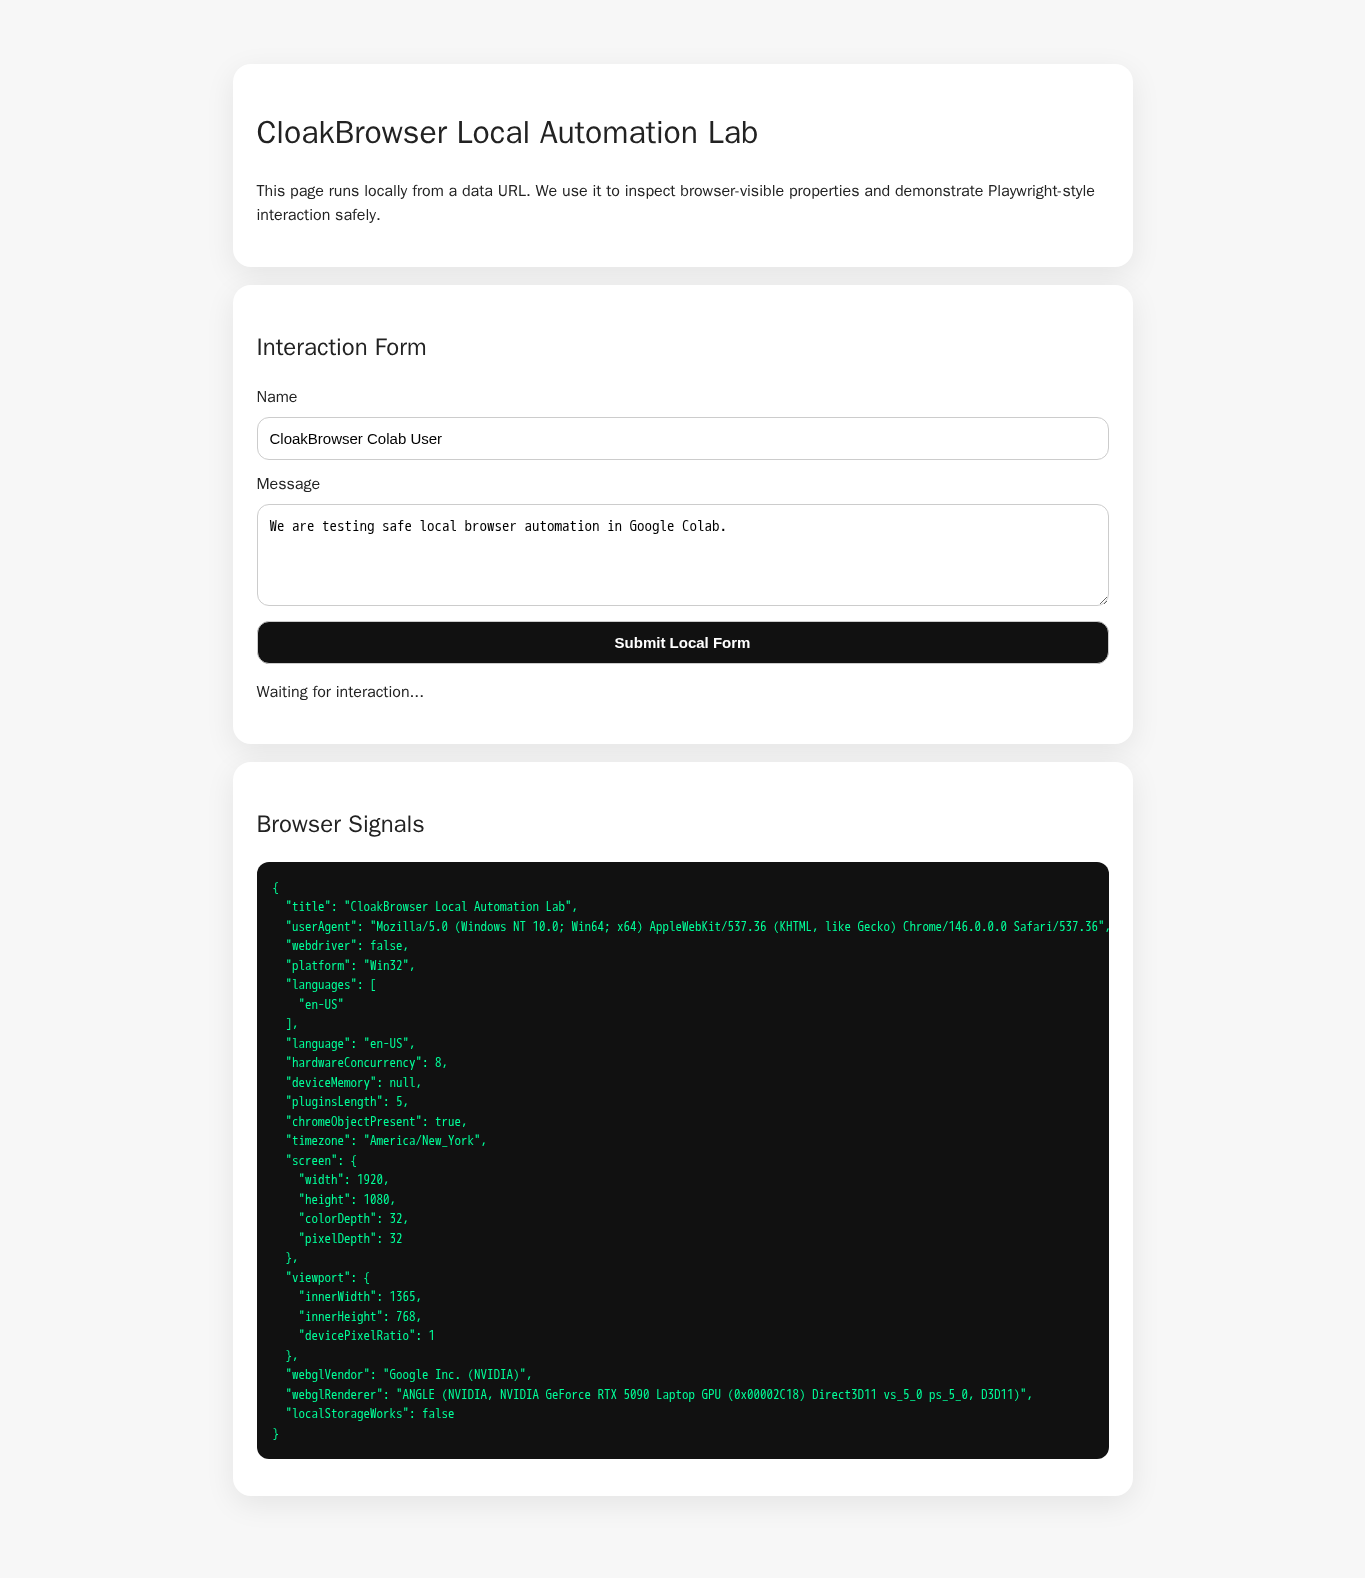

,category,metric,value
0,Browser signal,navigator.webdriver,False
1,Browser signal,navigator.plugins.length,5
2,Browser signal,window.chrome present,True
3,Browser signal,timezone,America/New_York
4,Browser signal,platform,Win32
5,Browser signal,viewport,"{""innerWidth"": 1365, ""innerHeight"": 768, ""devi..."
6,Browser signal,webglRenderer,"ANGLE (NVIDIA, NVIDIA GeForce RTX 5090 Laptop ..."
7,Navigation,basic launch title,Example Domain
8,Output,screenshot_path,/content/cloakbrowser_advanced_tutorial/cloakb...
9,Output,storage_state_path,/content/cloakbrowser_advanced_tutorial/storag...



Tutorial complete.
Files created:
 - /content/cloakbrowser_advanced_tutorial/cloakbrowser_result.png
 - /content/cloakbrowser_advanced_tutorial/persistent_profile
 - /content/cloakbrowser_advanced_tutorial/storage_state.json


In [2]:
tutorial_results = run_sync_browser_job_in_thread(cloakbrowser_tutorial_job)


print_section("6. Final tutorial summary")

if SCREENSHOT_PATH.exists():
    display(Image(filename=str(SCREENSHOT_PATH)))

rows = []

advanced = tutorial_results.get("advanced_context")

if advanced and advanced.get("signals"):
    signals = advanced["signals"]

    rows.extend([
        {
            "category": "Browser signal",
            "metric": "navigator.webdriver",
            "value": signals.get("webdriver"),
        },
        {
            "category": "Browser signal",
            "metric": "navigator.plugins.length",
            "value": signals.get("pluginsLength"),
        },
        {
            "category": "Browser signal",
            "metric": "window.chrome present",
            "value": signals.get("chromeObjectPresent"),
        },
        {
            "category": "Browser signal",
            "metric": "timezone",
            "value": signals.get("timezone"),
        },
        {
            "category": "Browser signal",
            "metric": "platform",
            "value": signals.get("platform"),
        },
        {
            "category": "Browser signal",
            "metric": "viewport",
            "value": json.dumps(signals.get("viewport")),
        },
        {
            "category": "Browser signal",
            "metric": "webglRenderer",
            "value": signals.get("webglRenderer"),
        },
    ])

persistent = tutorial_results.get("persistent_profile")

if persistent:
    rows.append({
        "category": "Persistence",
        "metric": "persistent profile restored localStorage",
        "value": persistent.get("persisted_successfully"),
    })

basic = tutorial_results.get("basic_launch")

if basic:
    rows.append({
        "category": "Navigation",
        "metric": "basic launch title",
        "value": basic.get("title"),
    })

rendered = tutorial_results.get("rendered_extraction")

if rendered:
    rows.append({
        "category": "Extraction",
        "metric": "rendered h1",
        "value": rendered.get("h1"),
    })

rows.extend([
    {
        "category": "Output",
        "metric": "screenshot_path",
        "value": str(SCREENSHOT_PATH) if SCREENSHOT_PATH.exists() else None,
    },
    {
        "category": "Output",
        "metric": "storage_state_path",
        "value": str(STORAGE_STATE_PATH) if STORAGE_STATE_PATH.exists() else None,
    },
    {
        "category": "Output",
        "metric": "working_directory",
        "value": str(WORKDIR),
    },
])

if tutorial_results.get("errors"):
    for err in tutorial_results["errors"]:
        rows.append({
            "category": "Error",
            "metric": err.get("section"),
            "value": err.get("error"),
        })

summary_df = pd.DataFrame(rows)
display(summary_df)

print("\nTutorial complete.")
print("Files created:")

for path in sorted(WORKDIR.glob("*")):
    print(" -", path)